# Convolutional Neural Networks: Cross-Correlation

> 📖 Book: [ch11 – Trees, forests and deep learning](../../.claude/skills/ml-knowledge/chapters/ch11-trees-forests-deep-learning.md) · Prev: [04 Forward propagation](../04_neural_networks/01_forward_propagation.ipynb) · Next: pooling and a full CNN (to do, see [ROADMAP](../../notes/ROADMAP.md))

## Introduction

Convolutional neural networks (CNNs, ConvNets) are a class of artificial neural networks widely used in deep learning to analyze images (2-D data), although they also work on 1-D signals and 3-D volumes.

CNNs were inspired by biology: their connectivity resembles the organization of the visual cortex. Individual cortical neurons respond to stimuli only in a restricted region of the visual field, their **receptive field**. Receptive fields of different neurons partially overlap so that together they cover the whole visual field.

The core building blocks are the **convolutional layers** that give the network its name. They do most of the heavy computation through an operation called "convolution" (in practice a *cross-correlation*, see below), which decomposes an image into elementary pieces using learned filters. The first convolutional layers extract simple features such as edges and contours; later layers combine them into higher-order features: edges compose into noses and eyes, and those compose into faces.

Applications of CNNs include image and video recognition, image classification and segmentation, medical image analysis, recommender systems, natural language processing, brain–computer interfaces, financial time series and anomaly detection.

## Architecture overview

A CNN is a composition of these blocks:

- **Convolution**: learned local pattern detectors with shared weights.
- **Subsampling (pooling)**: downsample, denoise, move to a coarser scale.
- **Dense (fully connected) layers**.
- **Classification** (softmax).

Input images are preprocessed (normalized/standardized) and then flow through convolution and pooling layers, which extract features and reduce redundancy. Simple features are combined by later convolutional layers into more complex ones. Finally the main features reach the dense layers, which perform the classification at the output.

![CNN architecture](../../reports/figures/cnn_architecture.png)

Further reading: [Stanford CS231n](http://cs231n.stanford.edu/), [Convolutional layers for deep learning (Machine Learning Mastery)](https://machinelearningmastery.com/convolutional-layers-for-deep-learning-neural-networks/).

## The inner product as a similarity measure

In signal processing, **cross-correlation** measures the similarity of two vectors as a function of the displacement of one relative to the other. It is used to compare time series or images, to decide objectively how well they match and, in particular, *where* the best match occurs. Applications: pattern recognition (deep learning), electron tomography, averaging, cryptanalysis, neurophysiology, ...

Cross-correlation is the inner product of a vector with a *sliding* copy of another vector, so it is also called the **sliding inner product**. Recall the inner product of $X = (x_i)$ and $Y = (y_i)$:

$$
\langle X, Y \rangle = X \cdot Y = \sum_i x_i y_i = \|X\| \|Y\| \cos \theta ,
$$

where $\theta$ is the angle between $X$ and $Y$ and $\|\cdot\|$ is the Euclidean ($\ell_2$) norm. Inner product spaces generalize Euclidean spaces to vector spaces of any (possibly infinite) dimension, and give rigorous meaning to length, angle and orthogonality (zero inner product).

A small distance $\|X - Y\|$ might look like a natural similarity measure, but it depends on the *size* of the vectors, not only their *shape*. Take

$$
X = \begin{pmatrix} 1 \\ -10 \\ 5 \end{pmatrix}, \quad
Y = \begin{pmatrix} 10 \\ -100 \\ 50 \end{pmatrix} = 10X .
$$

Their distance is large, $\|X - Y\| = \sqrt{9^2 + 90^2 + 45^2} \approx 101.02$, yet they have exactly the same shape. The cosine captures this:

$$
\cos \theta = \frac{X \cdot Y}{\|X\| \|Y\|} = \frac{10 + 1000 + 250}{\sqrt{126}\,\sqrt{12600}} = 1 .
$$

- $\cos \theta = 1$: the vectors are linearly dependent, maximum similarity;
- $\cos \theta = 0$: orthogonal, no correlation;
- $\cos \theta = -1$: total dissimilarity (opposite shapes).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ml.conv import cross_correlate

plt.style.use("seaborn-v0_8-whitegrid")

X = np.array([1.0, -10.0, 5.0])
Y = 10 * X
print(f"||X - Y|| = {np.linalg.norm(X - Y):.2f}")
print(f"cos(theta) = {X @ Y / (np.linalg.norm(X) * np.linalg.norm(Y)):.2f}")

||X - Y|| = 101.02
cos(theta) = 1.00


In signal and image processing the characteristic *shape* of a signal often matters more than its scale: $\sin t$ and $10 \sin t$ are the same wave, and we recognize a face in a dim image as well as in a bright one.

> **Note.** CNNs look for characteristic shapes and ignore the absolute scale of the images; normalizing the images is part of the preprocessing before the convolutional layers. That is why the normalization factor $\|X\|\|Y\|$ is dropped and the cheap inner product $X \cdot Y$ alone is used as the similarity measure.

## Cross-correlation of functions

Now suppose two functions are similar but one is a *shifted* copy of the other:

$$
f(t) = a_1 \cos(t + \phi), \quad g(t) = a_2 \cos t, \quad a_1, a_2, \phi \neq 0 .
$$

$f$ is obtained from $g$ by scaling by $a_1 / a_2$ and shifting by $\phi$. Ignoring the scale, the correlation of $f$ and $g$ is maximal when $g$ is shifted by $\phi$. When the phase is unknown we can shift $g$ little by little and keep the shift that maximizes the inner product. A left shift of $g$ by $\tau$ is $g(t + \tau)$, so we define

$$
(f \otimes g)(\tau) = \langle f(t), g(t + \tau) \rangle = \int_D f(t)\, g^*(t + \tau)\, dt ,
$$

where $D$ is the domain of $f$ and $g$, $g^*$ is the complex conjugate of $g$ (just $g$ for real data), and $(f \otimes g)(\tau)$ is the **cross-correlation** of $f$ and $g$. The function $f$ plays the role of the **filter** or **kernel**.

With $a_1 = a_2 = 1$, $D = [0, 2\pi]$ and $\phi = \pi$:

$$
(f \otimes g)(\tau) = \int_0^{2\pi} \cos(t + \pi) \cos(t + \tau)\, dt .
$$

Using $\cos \alpha \cos \beta = \tfrac{1}{2}[\cos(\alpha + \beta) + \cos(\alpha - \beta)]$, the first term integrates to zero over a full period and the second gives $\pi \cos(\pi - \tau)$, so

$$
(f \otimes g)(\tau) = -\pi \cos \tau ,
$$

which is maximal at $\tau = \pi = \phi$, as expected. Below, the numerical cross-correlation (`ml.conv.cross_correlate` of $f$ over two periods of $g$, times $\Delta t$) matches the closed form.

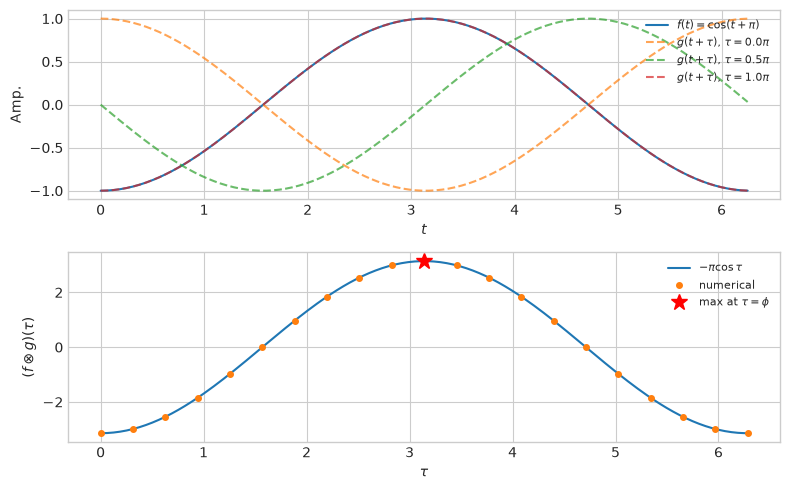

argmax tau / pi = 1.0000000000000002


In [2]:
phi = np.pi
n = 200
dt = 2 * np.pi / n
t = np.arange(n) * dt
f = np.cos(t + phi)                        # filter
g_long = np.cos(np.arange(2 * n) * dt)     # two periods of g, so every shift tau in [0, 2pi] fits
tau = np.arange(n + 1) * dt
z = cross_correlate(f, g_long) * dt        # Riemann sum of the integral

fig, ax = plt.subplots(2, 1, figsize=(8, 5))
ax[0].plot(t, f, label=r"$f(t) = \cos(t + \pi)$")
for s in [0.0, np.pi / 2, np.pi]:
    ax[0].plot(t, np.cos(t + s), "--", alpha=0.7, label=rf"$g(t + \tau)$, $\tau = {s / np.pi:.1f}\pi$")
ax[0].set_xlabel(r"$t$")
ax[0].set_ylabel("Amp.")
ax[0].legend(fontsize=8, loc="upper right")

ax[1].plot(tau, -np.pi * np.cos(tau), label=r"$-\pi\cos\tau$")
ax[1].plot(tau[::10], z[::10], "o", ms=4, label="numerical")
ax[1].plot(phi, np.pi, "r*", ms=12, label=r"max at $\tau = \phi$")
ax[1].set_xlabel(r"$\tau$")
ax[1].set_ylabel(r"$(f \otimes g)(\tau)$")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("argmax tau / pi =", tau[np.argmax(z)] / np.pi)

## Discrete cross-correlation (rank 1)

In practice cross-correlation is applied to data. For a filter $x_i$ and a signal $y_i$:

$$
z_j = \sum_i x_i\, y^*_{i + j} ,
$$

with $y^* = y$ for real data. Let the filter have length $N_x$ and the signal $N_y$, usually $N_x < N_y$. To stay inside both arrays we need $0 \le i < N_x$ and $0 \le i + j < N_y$, so

$$
z_j = \sum_{i=0}^{N_x - 1} x_i\, y_{i + j}, \quad j = 0, 1, \dots, N_y - N_x ,
$$

which gives $\#(z_j) = N_y - N_x + 1$ outputs ("valid" mode).

**Zero-padding.** To get $N_y$ outputs, add zeros at the borders of $y$: $N_x - 1$ zeros in total ($p = (N_x - 1)/2$ per side for odd $N_x$). Padding is very common in practice.

**Stride.** Cross-correlating large data is expensive, so we can skip outputs with a step $s > 1$:

$$
z_j = \sum_{i=0}^{N_x - 1} x_i\, y_{i + j}, \quad j = 0, s, 2s, \dots, ks \le N_y - N_x ,
$$

which cuts the work by a factor $s$. With $p$ zeros on each side the output size is

$$
\#(z_j) = \left\lfloor \frac{N_y - N_x + 2p}{s} \right\rfloor + 1 .
$$

In [3]:
y = np.arange(10.0)
x = np.array([1.0, 0.0, -1.0])            # a difference filter
for p, s in [(0, 1), (1, 1), (0, 2), (1, 3)]:
    z = cross_correlate(x, y, stride=s, padding=p)
    expected = (len(y) - len(x) + 2 * p) // s + 1
    print(f"p={p} s={s}: {len(z)} outputs (formula {expected}) -> {z}")

p=0 s=1: 8 outputs (formula 8) -> [-2. -2. -2. -2. -2. -2. -2. -2.]
p=1 s=1: 10 outputs (formula 10) -> [-1. -2. -2. -2. -2. -2. -2. -2. -2.  8.]
p=0 s=2: 4 outputs (formula 4) -> [-2. -2. -2. -2.]
p=1 s=3: 4 outputs (formula 4) -> [-1. -2. -2.  8.]


## Rank 2: images

For rank-2 objects the definition extends to

$$
(f \otimes g)(\tau, \rho) = \langle f(t, r), g(t + \tau, r + \rho) \rangle = \int_{D_r} \int_{D_t} f(t, r)\, g^*(t + \tau, r + \rho)\, dt\, dr ,
$$

assuming $f$ and $g$ are integrable on $D_t \times D_r$. For a filter $x_{mn}$ of size $M_x \times N_x$ and a matrix $y_{mn}$ of size $M_y \times N_y$ (with $M_x < M_y$, $N_x < N_y$):

$$
z_{ij} = \sum_{m=0}^{M_x - 1} \sum_{n=0}^{N_x - 1} x_{mn}\, y_{m+i,\,n+j}, \quad
\begin{aligned}
i &= 0, 1, \dots, M_y - M_x \\
j &= 0, 1, \dots, N_y - N_x
\end{aligned}
$$

so $\#(z_{ij}) = (M_y - M_x + 1) \times (N_y - N_x + 1)$. The filter slides over the input and each position produces one output value ([animation](https://miro.medium.com/max/625/1*GcI7G-JLAQiEoCON7xFbhg.gif), from [this guide](https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53)).

With zero-padding $p_M$ on the top and bottom and $p_N$ on the left and right:

$$
\#(z_{ij}) = (M_y - M_x + 2p_M + 1) \times (N_y - N_x + 2p_N + 1) .
$$

Choosing $p_M = (M_x - 1)/2$ and $p_N = (N_x - 1)/2$ (odd filter sizes) keeps the output the same size as $y$ ("same" mode):

![2-D cross-correlation with zero-padding](../../reports/figures/cross_correlation_2d_padding.png)

**Centered filter.** With odd filter sizes we can index the filter from its center: let $m_x = (M_x - 1)/2$, $n_x = (N_x - 1)/2$, then

$$
z_{ij} = \sum_{m=-m_x}^{m_x} \sum_{n=-n_x}^{n_x} x_{mn}\, y_{m+i,\,n+j}, \quad
\begin{aligned}
i &= m_x, \dots, M_y - m_x - 1 \\
j &= n_x, \dots, N_y - n_x - 1
\end{aligned}
$$

which is more symmetric and gives the same values (shifted indices).

**Example: edge detection.** A hand-made filter that responds to vertical edges, the kind of feature the first layer of a CNN learns on its own:

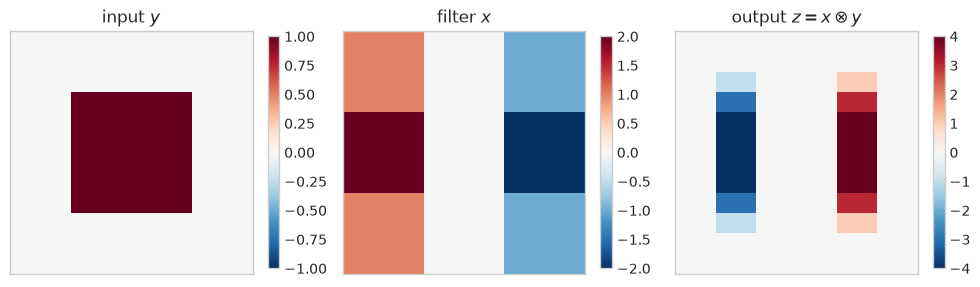

output shape: (12, 12)


In [4]:
img = np.zeros((12, 12))
img[3:9, 3:9] = 1.0                                         # a bright square
sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=float)

edges = cross_correlate(sobel_x, img, padding=1)            # "same" size: 12 x 12
fig, ax = plt.subplots(1, 3, figsize=(10, 3.2))
for a, im, title in zip(ax, [img, sobel_x, edges], ["input $y$", "filter $x$", r"output $z = x \otimes y$"]):
    h = a.imshow(im, cmap="RdBu_r", vmin=-np.abs(im).max(), vmax=np.abs(im).max())
    a.set_title(title)
    a.grid(False)
    a.set_xticks([])
    a.set_yticks([])
    fig.colorbar(h, ax=a, shrink=0.8)
plt.tight_layout()
plt.show()
print("output shape:", edges.shape)

## Rank 3: color images

Grayscale images have one channel. Color images (RGB, CMYK, HSV, ...) have several, so we need three indices: height, width and channel. A rank-3 array can be drawn as a cube:

![rank-3 tensor](../../reports/figures/rank3_tensor.png)

The continuous definition becomes

$$
(f \otimes g)(\tau, \rho, \xi) = \int_{D_s} \int_{D_r} \int_{D_t} f(t, r, s)\, g^*(t + \tau, r + \rho, s + \xi)\, dt\, dr\, ds ,
$$

and its discrete form

$$
z_{ijk} = \sum_{m=0}^{M_x - 1} \sum_{n=0}^{N_x - 1} \sum_{l=0}^{L_x - 1} x_{mnl}\, y_{m+i,\,n+j,\,l+k}, \quad
\begin{aligned}
i &= 0, 1, \dots, M_y - M_x \\
j &= 0, 1, \dots, N_y - N_x \\
k &= 0, 1, \dots, L_y - L_x
\end{aligned}
$$

where $M_x, N_x, L_x$ are the filter sizes along the three axes and $M_y, N_y, L_y$ those of the input.

> **In a CNN the filter is as deep as the input**, $L_x = L_y$ (3 for RGB). Then $k$ only takes the value 0: the filter does not slide along the channels, it **sums over them**, and each filter produces one 2-D output channel. A layer with $K$ filters outputs $K$ channels.

It is convenient to draw a rank-3 tensor as a stack of rank-2 slices. The figure shows one output value of a 3-channel cross-correlation with zero-padding $p = 1$: each channel is correlated with its own filter slice and the three results are added, $6 + 4 + 9 = 19$.

![3-D cross-correlation](../../reports/figures/cross_correlation_3d.png)

The cell below rebuilds the figure's input and filter and checks that value:

In [5]:
# figure data, one row per image row, (red, green, blue) channels
R = [[1, 2, 1, 2, 1], [1, 1, 2, 2, 0], [1, 0, 1, 0, 0], [2, 0, 2, 2, 2], [1, 1, 1, 1, 1]]
G = [[1, 0, 0, 1, 1], [5, 2, 0, 0, 3], [2, 0, 0, 2, 1], [1, 3, 0, 1, 4], [2, 0, 1, 0, 4]]
B = [[0, 1, 1, 1, 0], [0, 0, 1, 1, 1], [0, 1, 1, 1, 0], [0, 1, 0, 0, 0], [1, 0, 0, 0, 0]]
y_rgb = np.stack([R, G, B], axis=-1).astype(float)                     # 5 x 5 x 3

x_rgb = np.stack([[[2, 3, 0], [1, 0, 1], [0, 2, 0]],
                  [[1, 0, 1], [0, 1, 0], [1, 0, 1]],
                  [[0, 1, 8], [1, 5, 0], [0, 1, 2]]], axis=-1).astype(float)  # 3 x 3 x 3

y_pad = np.pad(y_rgb, ((1, 1), (1, 1), (0, 0)))                         # pad height and width only
z = cross_correlate(x_rgb, y_pad)[..., 0]                               # depth matches -> one channel
print("output shape:", z.shape)
print(z)
assert z[0, 3] == 19

output shape: (5, 5)
[[ 7. 16. 19. 19.  5.]
 [21. 28. 32. 20. 21.]
 [16. 27. 33. 39. 12.]
 [15. 30. 19. 16. 10.]
 [25.  9. 13. 16. 16.]]


**Stride in 3-D.** Instead of every output we can keep one every $s_M, s_N, s_L$ samples:

$$
i = 0, s_M, 2s_M, \dots \le M_y - M_x, \quad
j = 0, s_N, 2s_N, \dots \le N_y - N_x, \quad
k = 0, s_L, 2s_L, \dots \le L_y - L_x ,
$$

which saves memory and time by a factor $s_M s_N s_L$. Large strides lower the resolution of $z_{ijk}$: there is a trade-off between savings and output quality.

**Higher ranks.** The idea generalizes to tensors of any rank. A collection of RGB movies is a rank-5 tensor:

$$
\text{movie} \times \text{frame} \times \text{height} \times \text{width} \times \text{channel} .
$$

`ml.conv.cross_correlate` works for any rank, since it only slides a window of the filter's shape over the input.

## Summary

- Cross-correlation is a **sliding inner product**: it extracts spatial patches of the input and compares each with a filter. A high value means a good match.
- Because the same filter slides everywhere (**weight sharing**), it detects an object *wherever* it is in the image (translation equivariance), with far fewer parameters than a fully connected layer.
- Output size per axis: $\lfloor (N_y - N_x + 2p)/s \rfloor + 1$. "Same" padding for odd filters: $p = (N_x - 1)/2$.
- Deep-learning "convolution" is really cross-correlation (no filter flip). In a CNN the filter depth equals the input depth, and the number of output channels equals the number of filters.
- Cross-correlation is the centerpiece of CNNs; pooling, nonlinearities and dense layers complete the architecture.

## Exercises

1. Show that true convolution $(x * y)_j = \sum_i x_i\, y_{j - i}$ equals cross-correlation with the flipped filter $x_{N_x - 1 - i}$. Check it with `np.convolve` and `cross_correlate`.
2. A $32 \times 32 \times 3$ image goes through a layer of 16 filters of size $5 \times 5 \times 3$ with $p = 2$, $s = 1$. What is the output shape? How many weights (plus biases) does the layer have, compared with a dense layer producing the same number of outputs?
3. Design a $3 \times 3$ filter that detects horizontal edges and apply it to the square image above. What does a stride of 2 do to the output?